# Lineare Regression: Einkommen vorhersagen (`ConvertedTotalComp`)



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold


In [2]:

df = pd.read_csv("../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

df = df[df["ConvertedCompTotal"] > 10000].copy()

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


MaxAge                                                            float64
AgeNum                                                            float64
WorkExp                                                           float64
YearsCode                                                         float64
RemoteCategoryNum                                                 float64
                                                                   ...   
AIAgents_no, i use ai exclusively in copilot/autocomplete mode      int64
AIAgents_yes, i use ai agents at work daily                         int64
AIAgents_yes, i use ai agents at work monthly or infrequently       int64
AIAgents_yes, i use ai agents at work weekly                        int64
AIAgents_nan                                                        int64
Length: 484, dtype: object

In [3]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()
X = X.drop(columns=["ConvertedCompYearly"])


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (14415, 467) y: (14415,)


count     14415.000000
mean      97978.747468
std       59526.405376
min       10000.000000
25%       54983.898799
50%       85249.400000
75%      128927.870461
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [4]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
3     36435.36
7     72000.00
8     70000.00
Name: ConvertedCompTotal, dtype: float64

In [5]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (11532, 467) Test: (2883, 467)


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["MaxAge", "AgeNum", "WorkExp", "YearsCode", "RemoteCategoryNum"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


In [7]:
# Grid Search (Ridge / Lasso / ElasticNet) mit Preprocessing-Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge())  # Platzhalter
])

param_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1, 10, 100, 300, 1000]
    },
    {
        "model": [Lasso(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    {
        "model": [ElasticNet(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    }
]

#cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE minimieren
    cv=3,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("Bestes Modell:", grid.best_estimator_.named_steps["model"])
print("Beste Parameter:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

best_pipe = grid.best_estimator_
clf = best_pipe.named_steps["model"]  # für nachfolgende Zellen (Intercept / Coefs etc.)


/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.01222e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.51655e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.64263e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.64402e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/p

Bestes Modell: ElasticNet(alpha=0.01, l1_ratio=0.9, max_iter=20000)
Beste Parameter: {'model': ElasticNet(max_iter=20000), 'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Best CV RMSE: 38437.546745708416


In [8]:
# Prediction + Metriken (Best Model aus Grid Search)

predicted = best_pipe.predict(X_test)
expected = y_test

test_predict_mean = np.full(len(y_test), y_train.mean())
print("Baseline Mean RMSE:")
rmse_baseline = np.sqrt(mean_squared_error(expected, test_predict_mean))
print(rmse_baseline)

print("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print(rmse)

print("R^2:")
r2 = r2_score(expected, predicted)
print(r2)

print("MAE:")
mae = mean_absolute_error(expected, predicted)
print(mae)


Baseline Mean RMSE:
59177.48191537781
RMSE:
37759.634974974535
R^2:
0.5925651406723653
MAE:
26888.49427501088


In [9]:
# (Optional) Top-Ergebnisse aus der Cross-Validation (nach RMSE sortiert)

cv_res = pd.DataFrame(grid.cv_results_)
cols_show = ["rank_test_score", "mean_test_score", "std_test_score", "params"]
cv_res_sorted = cv_res[cols_show].sort_values("rank_test_score").head(10)

# RMSE aus neg_root_mean_squared_error zurückrechnen
cv_res_sorted = cv_res_sorted.assign(
    mean_RMSE = -cv_res_sorted["mean_test_score"],
    std_RMSE = cv_res_sorted["std_test_score"]
).drop(columns=["mean_test_score", "std_test_score"])

cv_res_sorted


,rank_test_score,params,mean_RMSE,std_RMSE
27,1,"{'model': ElasticNet(max_iter=20000), 'model__...",38437.546746,191.899866
18,2,"{'model': ElasticNet(max_iter=20000), 'model__...",38438.044336,196.305431
3,3,"{'model': Ridge(), 'model__alpha': 10}",38442.864958,178.299049
19,4,"{'model': ElasticNet(max_iter=20000), 'model__...",38445.320906,203.740551
20,5,"{'model': ElasticNet(max_iter=20000), 'model__...",38469.431979,206.409454
26,6,"{'model': ElasticNet(max_iter=20000), 'model__...",38537.893156,117.539671
21,7,"{'model': ElasticNet(max_iter=20000), 'model__...",38544.246287,200.530911
25,8,"{'model': ElasticNet(max_iter=20000), 'model__...",38690.079138,77.870169
2,9,"{'model': Ridge(), 'model__alpha': 1}",38802.424616,336.544311
24,10,"{'model': ElasticNet(max_iter=20000), 'model__...",38853.895041,62.555358


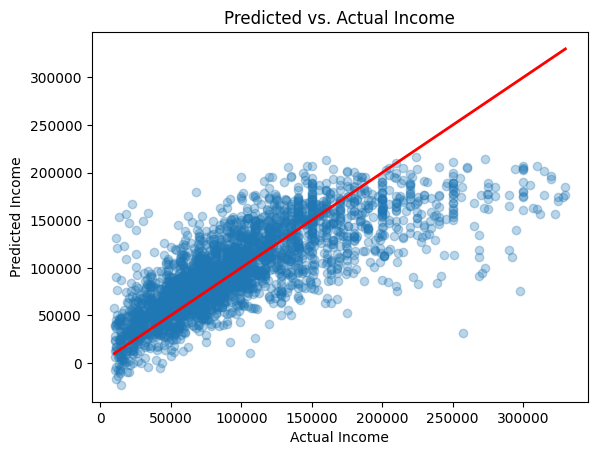

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



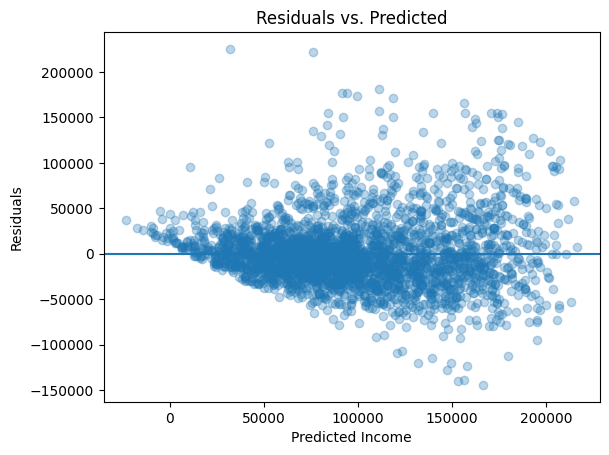

In [11]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


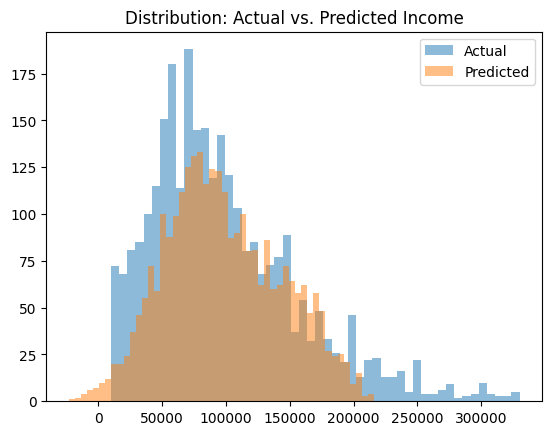

In [12]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()


In [13]:
print("Intercept:", clf.intercept_)

# Feature-Namen in der Reihenfolge des ColumnTransformers:
feature_names = num_cols + dummy_cols

coeff_df = pd.DataFrame({"Feature": feature_names, "Coefficient": clf.coef_})
print("\nFeature Coefficients:\n", coeff_df)


Intercept: 44999.574281320776

Feature Coefficients:
                                                Feature   Coefficient
0                                               MaxAge  -1761.157257
1                                               AgeNum  -4296.014225
2                                              WorkExp  12882.606625
3                                            YearsCode   6964.184546
4                                    RemoteCategoryNum  -3205.277981
..                                                 ...           ...
462  AIAgents_no, i use ai exclusively in copilot/a...  -1814.113868
463        AIAgents_yes, i use ai agents at work daily   1947.019202
464  AIAgents_yes, i use ai agents at work monthly ...   2224.088380
465       AIAgents_yes, i use ai agents at work weekly   2931.088797
466                                       AIAgents_nan  -2651.850375

[467 rows x 2 columns]


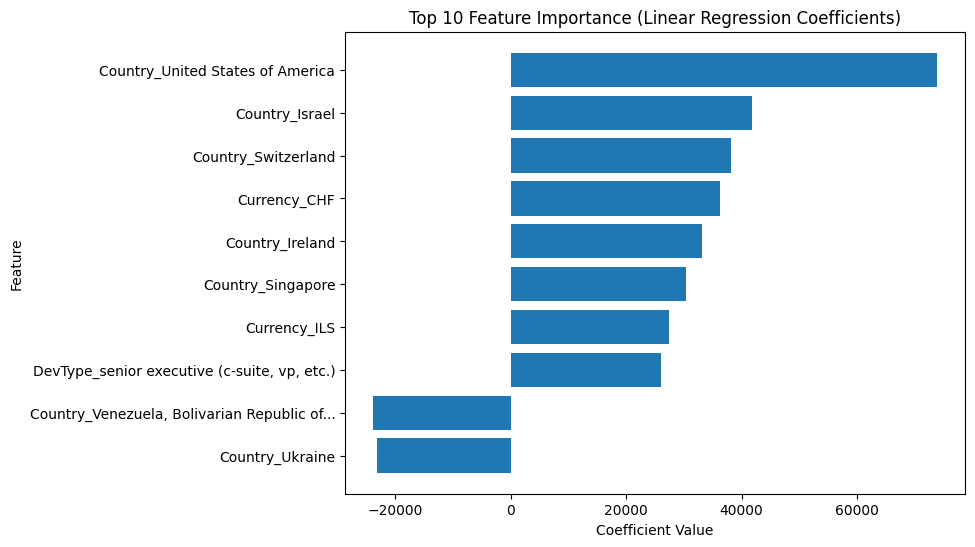

In [14]:
# Sort by absolute coefficient value and take top 10
coef_df_sorted = (
    coeff_df
    .assign(abs_coef=coeff_df["Coefficient"].abs())
    .sort_values(by="abs_coef", ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Linear Regression Coefficients)")
plt.gca().invert_yaxis()  # highest importance on top
plt.show()


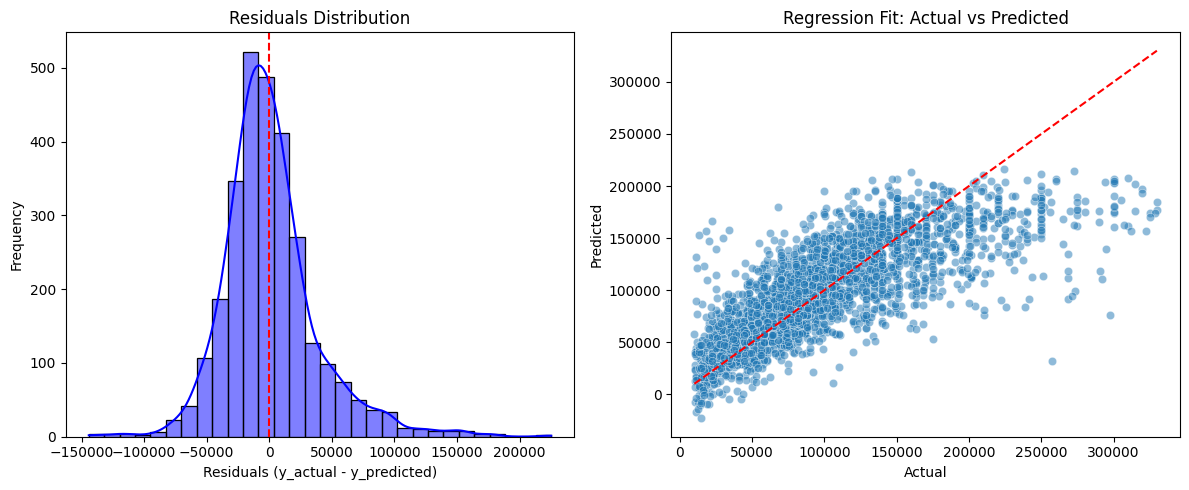

In [15]:
# Compute residuals.
residuals = expected - predicted

# Create plots.
plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=expected, y=predicted, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")


# Show plots.
plt.tight_layout()
plt.show()